# Прогнозирование удоя и качества молока для отбора коров

## О проекте

В этом исследовании решается прикладная задача отбора коров для расширения стада.  
Цель — снизить риск неудачной покупки и сделать решение о закупке более объективным на основе данных.

## Бизнес-контекст

Фермеру важно оценивать животных по двум критериям:

1. **Прогнозируемый годовой удой** — не ниже целевого уровня.
2. **Ожидаемое качество молока** — молоко должно соответствовать внутренним требованиям по вкусу.

Из этого следуют две связанные задачи машинного обучения:

- **регрессия** — прогноз значения `удой_кг`;
- **классификация** — прогноз признака `вкус_молока`.

## Практическая цель решения

Итогом работы должен стать список коров, которых можно рекомендовать к покупке с минимальным риском.  
Для этого объединяются результаты двух моделей: корова считается подходящей, если у неё ожидается достаточный удой и приемлемая вероятность того, что молоко будет вкусным.

## Источники данных

В работе используются три таблицы:

- `ferma_main.csv` — текущие данные по стаду;
- `ferma_dad.csv` — информация об отцах коров;
- `cow_buy.csv` — данные по коровам, доступным к покупке.


## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin

# Чтобы графики были аккуратнее
plt.rcParams["figure.figsize"] = (8, 5)

## Вспомогательные функции


In [2]:
# =========================
# ФУНКЦИИ ПРЕДОБРАБОТКИ
# =========================
import re

def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Нормализует названия столбцов:
    - lower
    - пробелы/табы -> _
    - дефисы разных типов (-, –, —) -> _
    - запятые удаляются
    - % -> pct
    - скобки удаляются
    - множественные _ схлопываются
    """
    df = df.copy()
    cols = df.columns.astype(str).str.lower().str.strip()

    # Пробельные символы -> _
    cols = cols.str.replace(r"\s+", "_", regex=True)

    # Разные типы дефисов -> _
    cols = cols.str.replace("—", "_", regex=False).str.replace("–", "_", regex=False).str.replace("-", "_", regex=False)

    # Запятые убираем, проценты нормализуем
    cols = cols.str.replace(",", "", regex=False).str.replace("%", "pct", regex=False)

    # Скобки удаляем
    cols = cols.str.replace("(", "", regex=False).str.replace(")", "", regex=False)

    # Схлопываем повторяющиеся _ и убираем _ по краям
    cols = cols.str.replace(r"_+", "_", regex=True).str.strip("_")

    df.columns = cols
    return df


def to_float_with_comma(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """
    Преобразует числа, записанные строками с запятой, в float.
    """
    df = df.copy()
    for col in cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )
    return df


## Загрузка данных


In [3]:
# Пути
path_main = "/datasets/ferma_main.csv"
path_dad  = "/datasets/ferma_dad.csv"
path_buy  = "/datasets/cow_buy.csv"

# Читаем с sep=';'
ferma_main = pd.read_csv(path_main, sep=';')
ferma_dad  = pd.read_csv(path_dad,  sep=';')
cow_buy    = pd.read_csv(path_buy,  sep=';')

print("ferma_main:", ferma_main.shape)
display(ferma_main.head())

print("ferma_dad:", ferma_dad.shape)
display(ferma_dad.head())

print("cow_buy:", cow_buy.shape)
display(cow_buy.head())


ferma_main: (634, 12)


,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


ferma_dad: (629, 2)


,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


cow_buy: (20, 7)


,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


In [4]:
# Общая структура
display(ferma_main.info())
display(ferma_dad.info())
display(cow_buy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


None

## Предобработка данных


### Нормализация названий столбцов


In [5]:
# =========================
# 1. Нормализация названий столбцов
# =========================
ferma_main = clean_columns(ferma_main)
ferma_dad  = clean_columns(ferma_dad)
cow_buy    = clean_columns(cow_buy)

# =========================
# Приведение cow_buy к формату, совместимому с моделями
# =========================

# 1) Добавим id, так как в cow_buy его нет (в твоём файле)
#    Это нужно для финальных рекомендаций и идентификации строк
cow_buy = cow_buy.copy()
cow_buy["id"] = [f"buy_{i:03d}" for i in range(1, len(cow_buy) + 1)]

# 2) Приведём "текущие" показатели молока к именам, ожидаемым моделями
#    После clean_columns они становятся:
#      "текущая_жирностьpct", "текущий_уровень_белокpct"
rename_map = {
    "текущая_жирностьpct": "жирностьpct",
    "текущий_уровень_белокpct": "белокpct",
}
cow_buy = cow_buy.rename(columns=rename_map)

# 3) Типы данных для жирности/белка (на случай запятых)
for col in ["жирностьpct", "белокpct"]:
    if col in cow_buy.columns:
        cow_buy[col] = (
            cow_buy[col]
            .astype(str)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

display(cow_buy.head())
print("cow_buy columns:", list(cow_buy.columns))



display(ferma_main.columns)

,порода,тип_пастбища,порода_папы_быка,имя_папы,жирностьpct,белокpct,возраст,id
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,buy_001
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,buy_002
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,buy_003
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,buy_004
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,buy_005


cow_buy columns: ['порода', 'тип_пастбища', 'порода_папы_быка', 'имя_папы', 'жирностьpct', 'белокpct', 'возраст', 'id']


Index(['id', 'удой_кг', 'эке_энергетическая_кормовая_единица',
       'сырой_протеин_г', 'спо_сахаро_протеиновое_соотношение', 'порода',
       'тип_пастбища', 'порода_папы_быка', 'жирностьpct', 'белокpct',
       'вкус_молока', 'возраст'],
      dtype='object')

### Проверка пропусков и дубликатов


In [6]:
# =========================
# 2. Проверка пропусков и дубликатов (ДО удаления)
# =========================

print("Пропуски по столбцам:")
display(ferma_main.isna().sum())

print("\nДубликаты строк:", ferma_main.duplicated().sum())
print("Дубликаты по id:", ferma_main["id"].duplicated().sum())

Пропуски по столбцам:


id                                     0
удой_кг                                0
эке_энергетическая_кормовая_единица    0
сырой_протеин_г                        0
спо_сахаро_протеиновое_соотношение     0
порода                                 0
тип_пастбища                           0
порода_папы_быка                       0
жирностьpct                            0
белокpct                               0
вкус_молока                            0
возраст                                0
dtype: int64


Дубликаты строк: 5
Дубликаты по id: 5


### Удаление дубликатов


In [7]:
# =========================
# 3. Удаление дубликатов
# =========================

# удаляем полные дубликаты
ferma_main = ferma_main.drop_duplicates()

# оставляем одну запись на каждую корову
ferma_main = ferma_main.drop_duplicates(subset=["id"], keep="first")

print("После очистки:")
print("  shape:", ferma_main.shape)
print("  dup rows:", ferma_main.duplicated().sum())
print("  dup id:", ferma_main["id"].duplicated().sum())

После очистки:
  shape: (629, 12)
  dup rows: 0
  dup id: 0


### Приведение признака СПО к единому имени


In [8]:
# =========================
# 4. Приведение СПО к каноническому имени
# =========================

spo_candidates = [c for c in ferma_main.columns if c.startswith("спо_")]

if len(spo_candidates) == 1:
    ferma_main = ferma_main.rename(
        columns={spo_candidates[0]: "спо_сахаро_протеиновое_соотношение"}
    )
else:
    raise ValueError(f"Ожидался один столбец СПО, найдено: {spo_candidates}")

display([c for c in ferma_main.columns if "спо" in c])

['спо_сахаро_протеиновое_соотношение']

### Приведение числовых признаков к типу `float`


In [9]:
# =========================
# 5. Приведение числовых признаков к float
# =========================

num_cols_main = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

ferma_main = to_float_with_comma(ferma_main, num_cols_main)

display(ferma_main[num_cols_main].dtypes)
display(ferma_main[num_cols_main].head())

удой_кг                                float64
эке_энергетическая_кормовая_единица    float64
сырой_протеин_г                        float64
спо_сахаро_протеиновое_соотношение     float64
жирностьpct                            float64
белокpct                               float64
dtype: object

,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,жирностьpct,белокpct
0,5863.0,14.2,1743.0,0.890,3.58,3.076
1,5529.0,12.8,2138.0,0.890,3.54,3.079
2,5810.0,14.0,1854.0,0.885,3.59,3.074
3,5895.0,12.4,2012.0,0.885,3.40,3.075
4,5302.0,12.8,1675.0,0.885,3.73,3.073


### Кодирование целевого признака для классификации


In [10]:
# =========================
# 6. Кодирование целевого признака для классификации (устойчиво)
# =========================

# 1) Посмотрим исходные уникальные значения
print("Уникальные значения ДО обработки:")
display(ferma_main["вкус_молока"].astype(str).value_counts(dropna=False).head(20))

# 2) Нормализуем строки: нижний регистр, убрать лишние пробелы, заменить множественные пробелы на один
taste_raw = (
    ferma_main["вкус_молока"]
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# 3) Приводим варианты написания к двум классам
# (наиболее частые варианты: "вкусно" и "не вкусно")
taste_raw = taste_raw.replace({
    "невкусно": "не вкусно",
    "не_вкусно": "не вкусно",
    "не вкусное": "не вкусно",
    "невкусное": "не вкусно",
})

# 4) Маппинг в 0/1
ferma_main["вкус_молока"] = taste_raw.map({
    "вкусно": 1,
    "не вкусно": 0
})

# 5) Контроль результата
print("\nБаланс классов ПОСЛЕ кодирования:")
display(ferma_main["вкус_молока"].value_counts(dropna=False))

# 6) Если остались NaN — покажем, что именно не распознано
bad = taste_raw[ferma_main["вкус_молока"].isna()].value_counts()
if bad.shape[0] > 0:
    print("\nВНИМАНИЕ: есть значения, которые не удалось закодировать. Вот они:")
    display(bad.head(20))


Уникальные значения ДО обработки:


вкусно       371
не вкусно    258
Name: вкус_молока, dtype: int64


Баланс классов ПОСЛЕ кодирования:


1    371
0    258
Name: вкус_молока, dtype: int64

### Вывод по предобработке


Данные приведены к единому рабочему формату:

- нормализованы названия признаков;
- удалены полные дубликаты и повторные записи по `id`;
- числовые признаки приведены к типу `float`;
- целевой признак `вкус_молока` переведён в бинарный формат для задачи классификации.

Пропуски в основных таблицах не выявлены. Это упрощает построение пайплайнов и позволяет сосредоточиться на качестве признаков и поведении моделей.


## Исследовательский анализ данных


### Структура датасета после предобработки


In [11]:
# =========================
# 1. Общая информация о датасете после предобработки
# =========================
print("Размер датасета:", ferma_main.shape)
display(ferma_main.head())


Размер датасета: (629, 12)


,id,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,порода,тип_пастбища,порода_папы_быка,жирностьpct,белокpct,вкус_молока,возраст
0,1,5863.0,14.2,1743.0,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,1,более_2_лет
1,2,5529.0,12.8,2138.0,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,1,менее_2_лет
2,3,5810.0,14.0,1854.0,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,0,более_2_лет
3,4,5895.0,12.4,2012.0,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,0,более_2_лет
4,5,5302.0,12.8,1675.0,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,1,менее_2_лет


### Описательная статистика числовых признаков


In [12]:
# =========================
# 2. Описательная статистика числовых признаков
# =========================

num_cols = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

display(ferma_main[num_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
удой_кг,629.0,6188.750397,1644.795489,5204.000,5751.000,6133.000,6501.000,45616.000
эке_энергетическая_кормовая_единица,629.0,14.543879,1.306408,10.900,13.500,14.700,15.600,16.800
сырой_протеин_г,629.0,1923.364070,182.956251,1660.000,1771.000,1888.000,2062.000,2349.000
спо_сахаро_протеиновое_соотношение,629.0,0.913116,0.032203,0.840,0.890,0.930,0.940,0.960
жирностьpct,629.0,3.603657,0.168656,2.990,3.590,3.650,3.720,3.750
белокpct,629.0,3.075671,0.002549,3.069,3.074,3.076,3.077,3.085


### Распределение целевых признаков


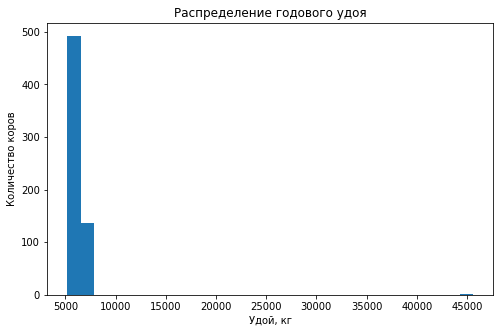

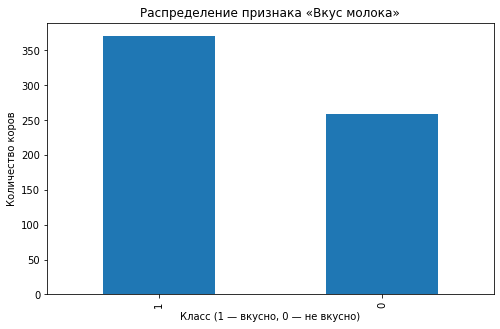

In [13]:
# =========================
# 3. Распределение целевых признаков
# =========================

# Удой
plt.hist(ferma_main["удой_кг"], bins=30)
plt.title("Распределение годового удоя")
plt.xlabel("Удой, кг")
plt.ylabel("Количество коров")
plt.show()

# Вкус молока
ferma_main["вкус_молока"].value_counts().plot(kind="bar")
plt.title("Распределение признака «Вкус молока»")
plt.xlabel("Класс (1 — вкусно, 0 — не вкусно)")
plt.ylabel("Количество коров")
plt.show()


### Boxplot-анализ и проверка выбросов


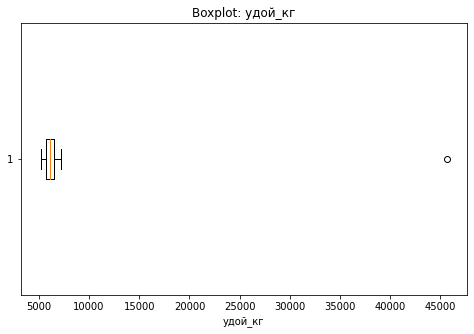

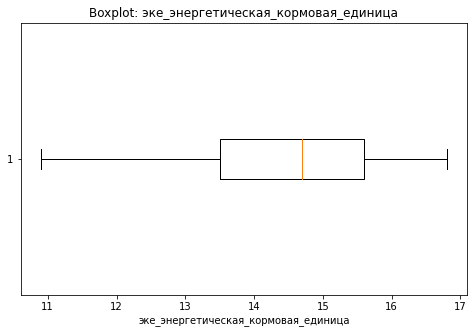

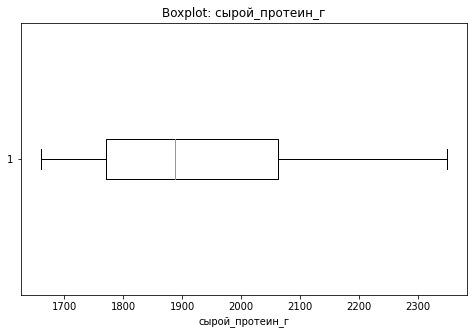

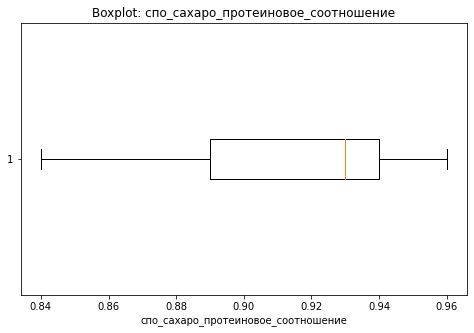

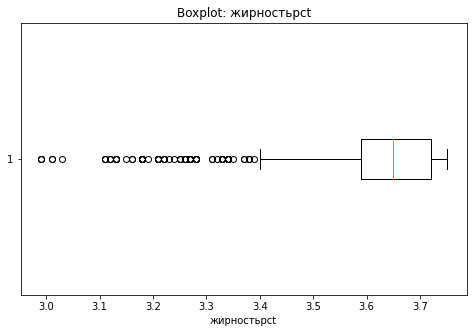

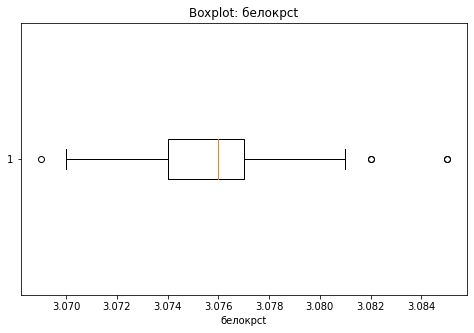

In [14]:
# =========================
# 4. Boxplot для выявления выбросов
# =========================

for col in num_cols:
    plt.figure()
    plt.boxplot(ferma_main[col], vert=False)
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()


In [15]:
# =========================
# Удаление выброса по удою (одна строка)
# =========================

# Найдём наблюдение с максимальным удоем
outlier_idx = ferma_main["удой_кг"].idxmax()
outlier_value = ferma_main.loc[outlier_idx, "удой_кг"]

print("Удаляем выброс:")
display(ferma_main.loc[[outlier_idx]])

# Удаляем строку
ferma_main = ferma_main.drop(index=outlier_idx).reset_index(drop=True)

print(f"Удалено наблюдение с удоем = {outlier_value}")
print("Новый размер датасета:", ferma_main.shape)


Удаляем выброс:


,id,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,порода,тип_пастбища,порода_папы_быка,жирностьpct,белокpct,вкус_молока,возраст
16,17,45616.0,11.5,1675.0,0.93,Вис Бик Айдиал,Холмистое,Айдиалл,3.22,3.076,1,более_2_лет


Удалено наблюдение с удоем = 45616.0
Новый размер датасета: (628, 12)


### Распределение категориальных признаков


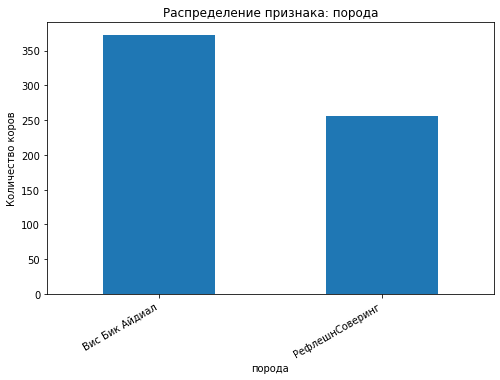

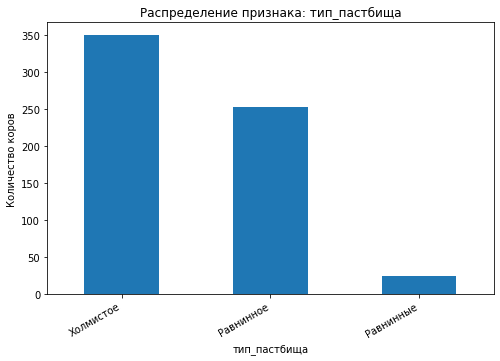

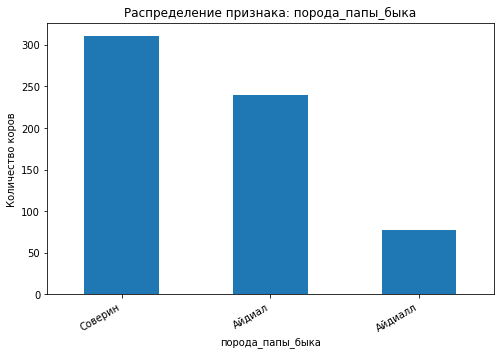

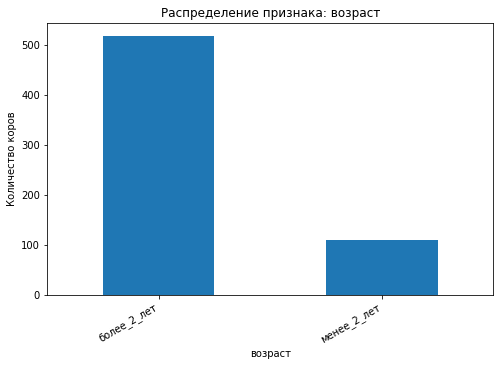

In [16]:
# =========================
# 5. Распределение категориальных признаков
# =========================

cat_cols = [
    "порода",
    "тип_пастбища",
    "порода_папы_быка",
    "возраст",
]

for col in cat_cols:
    ferma_main[col].value_counts().plot(kind="bar")
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество коров")
    plt.xticks(rotation=30, ha="right")
    plt.show()


### Сравнение средних значений в разрезе вкуса молока


In [17]:
# =========================
# 6. Средние значения признаков в разрезе вкуса молока
# =========================

group_means = ferma_main.groupby("вкус_молока")[num_cols].mean()
display(group_means)


,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,жирностьpct,белокpct
вкус_молока,,,,,,
0,6061.717054,14.214729,1891.248062,0.905795,3.585310,3.075279
1,6170.770270,14.781622,1946.429730,0.918176,3.617486,3.075943


### Вывод по исследовательскому анализу

Исследовательский анализ показал несколько важных особенностей данных:

- числовые признаки распределены неоднородно;
- для части признаков наблюдаются выбросы, что характерно для реальных производственных данных;
- целевой признак `вкус_молока` умеренно несбалансирован, но дисбаланс не критический.

Отдельно был проверен признак `удой_кг`. На boxplot обнаружено единичное экстремальное наблюдение, заметно удалённое от основной массы значений. Поскольку линейная регрессия чувствительна к выбросам, такая точка может существенно влиять на коэффициенты и ухудшать устойчивость модели. Поэтому аномальное наблюдение было исключено из дальнейшего моделирования.

Категориальные признаки содержат ограниченное число уникальных значений, поэтому их удобно кодировать через One-Hot Encoding. Анализ средних значений также показывает, что между группами по вкусу молока есть различия, а значит часть признаков потенциально полезна и для классификации.


## Корреляционный анализ


### Корреляционная матрица числовых признаков


In [18]:
# =========================
# 1. Корреляционная матрица числовых признаков
# =========================

num_cols = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

corr_matrix = ferma_main[num_cols].corr()

display(corr_matrix)

,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,жирностьpct,белокpct
удой_кг,1.000000,0.765098,0.446731,0.806339,0.600902,0.002966
эке_энергетическая_кормовая_единица,0.765098,1.000000,0.387875,0.749007,0.637279,-0.008939
сырой_протеин_г,0.446731,0.387875,1.000000,0.446332,0.357793,0.226802
спо_сахаро_протеиновое_соотношение,0.806339,0.749007,0.446332,1.000000,0.629098,0.073718
жирностьpct,0.600902,0.637279,0.357793,0.629098,1.000000,-0.026542
белокpct,0.002966,-0.008939,0.226802,0.073718,-0.026542,1.000000


### Связь признаков с целевой переменной `удой_кг`


In [19]:
# =========================
# 2. Корреляция признаков с целевым показателем удоя
# =========================

corr_with_target = corr_matrix["удой_кг"].sort_values(ascending=False)
display(corr_with_target)


удой_кг                                1.000000
спо_сахаро_протеиновое_соотношение     0.806339
эке_энергетическая_кормовая_единица    0.765098
жирностьpct                            0.600902
сырой_протеин_г                        0.446731
белокpct                               0.002966
Name: удой_кг, dtype: float64

### Диаграммы рассеяния: удой и числовые признаки


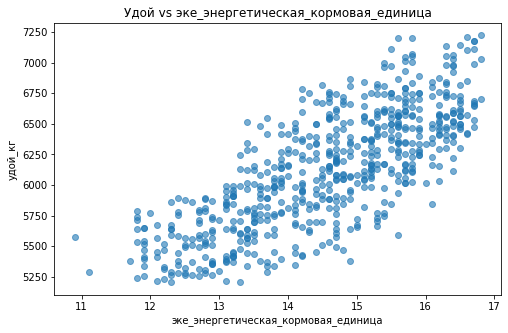

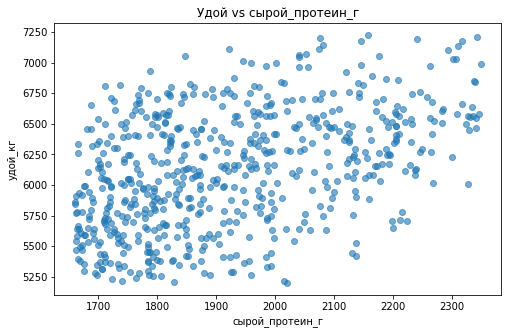

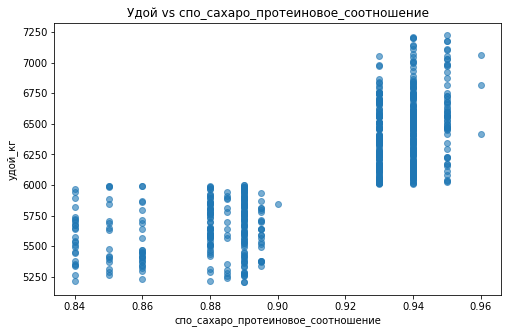

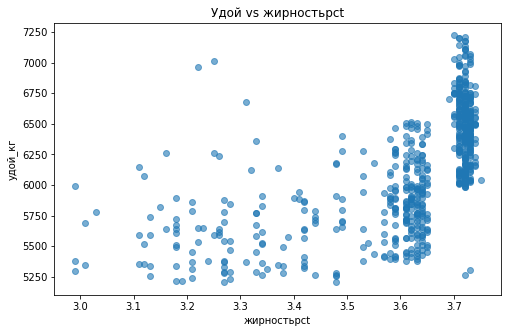

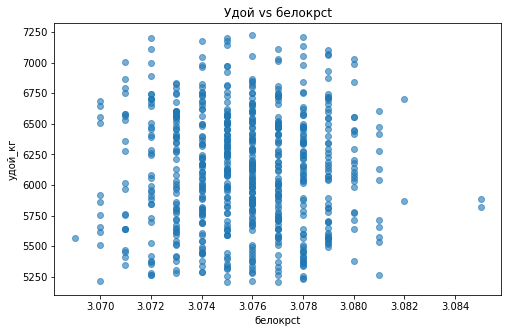

In [20]:
# =========================
# 3. Scatterplot: удой vs числовые признаки
# =========================

for col in num_cols:
    if col == "удой_кг":
        continue
    plt.figure()
    plt.scatter(
        ferma_main[col],
        ferma_main["удой_кг"],
        alpha=0.6
    )
    plt.xlabel(col)
    plt.ylabel("удой_кг")
    plt.title(f"Удой vs {col}")
    plt.show()


### Кормовые признаки и удой в разрезе породы


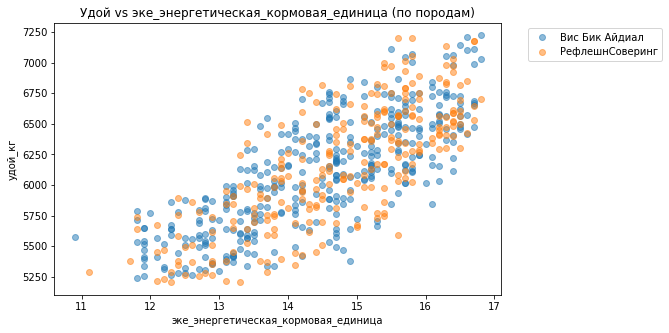

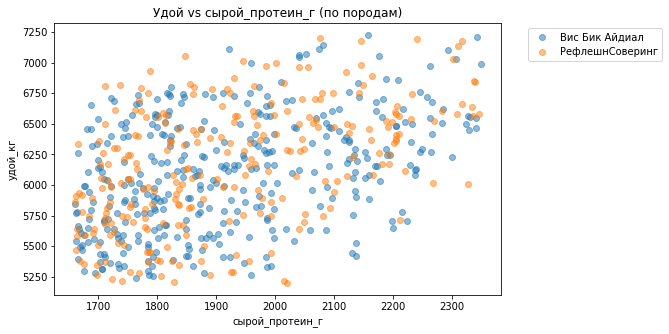

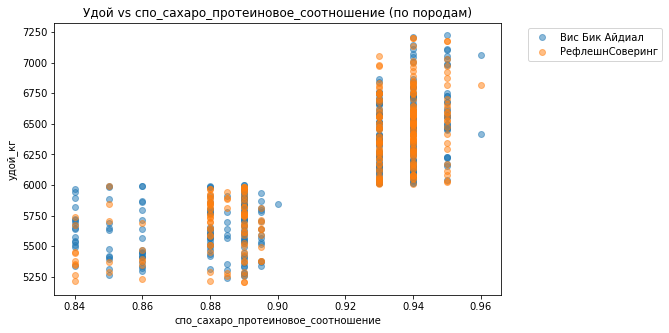

In [21]:
# =========================
# 4. Удой и кормовые признаки в разрезе породы
# =========================

for col in ["эке_энергетическая_кормовая_единица", "сырой_протеин_г", "спо_сахаро_протеиновое_соотношение"]:
    plt.figure()
    for breed in ferma_main["порода"].unique():
        subset = ferma_main[ferma_main["порода"] == breed]
        plt.scatter(
            subset[col],
            subset["удой_кг"],
            alpha=0.5,
            label=breed
        )
    plt.xlabel(col)
    plt.ylabel("удой_кг")
    plt.title(f"Удой vs {col} (по породам)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.show()


### Корреляции между входными признаками


In [22]:
# =========================
# 5. Корреляции между входными признаками (без удоя)
# =========================

input_corr = ferma_main[num_cols].drop(columns=["удой_кг"]).corr()
display(input_corr)

,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,жирностьpct,белокpct
эке_энергетическая_кормовая_единица,1.000000,0.387875,0.749007,0.637279,-0.008939
сырой_протеин_г,0.387875,1.000000,0.446332,0.357793,0.226802
спо_сахаро_протеиновое_соотношение,0.749007,0.446332,1.000000,0.629098,0.073718
жирностьpct,0.637279,0.357793,0.629098,1.000000,-0.026542
белокpct,-0.008939,0.226802,0.073718,-0.026542,1.000000


### Вывод по корреляционному анализу

Корреляционный анализ показывает, что наиболее заметная связь с годовым удоем наблюдается у кормовых характеристик, прежде всего у энергетической кормовой единицы и содержания сырого протеина. При этом часть зависимостей выглядит не полностью линейной, что важно учитывать при построении линейной регрессии.

По диаграммам рассеяния видно, что для некоторых признаков возможны кластеризация и нелинейные эффекты. Это стало основанием для проверки альтернативной спецификации модели с дополнительным преобразованием признаков.

Сильной мультиколлинеарности между основными входными признаками не наблюдается, однако умеренные корреляции между кормовыми параметрами присутствуют и требуют аккуратной интерпретации коэффициентов.


Корреляционный анализ показал наличие положительной связи между годовым удоем и кормовыми показателями, в первую очередь с энергетической кормовой единицей и содержанием сырого протеина. Связь между удоем и показателем СПО носит нелинейный характер, что подтверждается формой диаграмм рассеяния.

Диаграммы рассеяния в разрезе пород показывают, что характер связи между признаками может различаться в подгруппах, что следует учитывать при интерпретации модели.

Между отдельными входными признаками наблюдается умеренная корреляция, однако признаков сильной мультиколлинеарности не выявлено.

Полученные результаты указывают на целесообразность использования линейной регрессии, а также на необходимость дополнительной обработки отдельных признаков для устранения нелинейности, в частности для показателя СПО и энергетической кормовой единицы.

## Регрессионная модель: прогноз годового удоя


### Формирование набора признаков


In [23]:
# =========================
# 1. Подготовка данных
# =========================

target = "удой_кг"

num_features = [
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

cat_features = [
    "порода",
    "тип_пастбища",
    "порода_папы_быка",
    "возраст",
]

X = ferma_main[num_features + cat_features]
y = ferma_main[target]


### Разделение на обучающую и тестовую выборки


In [24]:
# =========================
# 2. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


### Пайплайн подготовки данных и обучения


In [25]:
# =========================
# 3. Pipeline
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

model_lr_1 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

### Обучение базовой модели


In [26]:
# =========================
# 4. Обучение модели
# =========================

model_lr_1.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['эке_энергетическая_кормовая_единица',
                                                   'сырой_протеин_г',
                                                   'спо_сахаро_протеиновое_соотношение',
                                                   'жирностьpct', 'белокpct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['порода', 'тип_пастбища',
                                                   'порода_папы_быка',
                                                   'возраст'])])),
                ('model', LinearRegression())])

### Качество модели на тестовой выборке


In [27]:
# =========================
# 5. Оценка качества
# =========================
y_pred = model_lr_1.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print(f"R²:   {r2:.3f}")
print(f"MAE:  {mae:.1f}")
print(f"RMSE: {rmse:.1f}")

R²:   0.805
MAE:  153.8
RMSE: 199.1


### Анализ остатков


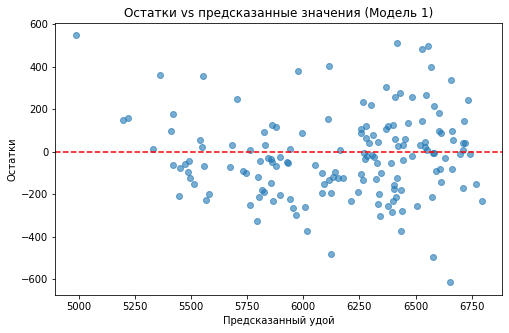

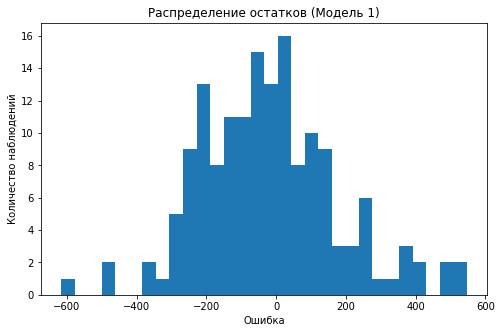

In [28]:
# =========================
# 6. Анализ остатков
# =========================
residuals = y_test - y_pred

# Остатки vs предсказания
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("Остатки vs предсказанные значения (Модель 1)")
plt.show()

# Распределение остатков
plt.hist(residuals, bins=30)
plt.title("Распределение остатков (Модель 1)")
plt.xlabel("Ошибка")
plt.ylabel("Количество наблюдений")
plt.show()

### Вывод по модели 1

Базовая линейная регрессия используется как отправная точка. Она позволяет оценить, насколько исходные признаки вообще объясняют вариацию годового удоя без дополнительного усложнения модели.

Основной акцент в интерпретации сделан не только на `R²`, но и на анализе остатков: именно он показывает, насколько систематическими являются ошибки модели и есть ли в данных структура, которую линейная зависимость не улавливает.


Была обучена базовая модель линейной регрессии для прогнозирования годового удоя коров. Модель показала умеренное значение коэффициента детерминации R², что свидетельствует о наличии объясняемого сигнала в данных, однако указывает на неполное описание зависимости между входными признаками и целевой переменной.

Анализ остатков показывает наличие систематических отклонений и неоднородность дисперсии, что может быть связано с нелинейным характером связи между удоем и отдельными признаками, а также с влиянием факторов, не учтённых в модели.

Полученные результаты подтверждают необходимость дальнейшего улучшения модели путём дополнительной обработки признаков и учёта нелинейных эффектов.

## Регрессионная модель: вариант 2
### Устранение нелинейности (`СПО` + `ЭКЕ²`)


### Feature engineering на основе результатов анализа


In [29]:
# =========================
# Модель 2 (без утечки): кастомный трансформер
# =========================

class SpoEkeFeatures(BaseEstimator, TransformerMixin):
    """
    fit: запоминает медиану СПО на train
    transform: добавляет признаки:
      - spo_high (>= median_spo)
      - эке_квадрат
    """
    def __init__(self, spo_col="спо_сахаро_протеиновое_соотношение",
                 eke_col="эке_энергетическая_кормовая_единица"):
        self.spo_col = spo_col
        self.eke_col = eke_col
        self.spo_median_ = None

    def fit(self, X, y=None):
        X_ = X.copy()
        self.spo_median_ = X_[self.spo_col].median()
        return self

    def transform(self, X):
        X_ = X.copy()
        X_["spo_high"] = (X_[self.spo_col] >= self.spo_median_).astype(int)
        X_["эке_квадрат"] = X_[self.eke_col] ** 2
        return X_

### Формирование `X` и `y`, разбиение выборки


In [30]:
# =========================
# 2. Подготовка данных
# =========================
target = "удой_кг"

base_num = [
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]
cat_features = [
    "порода",
    "тип_пастбища",
    "порода_папы_быка",
    "возраст",
]

X = ferma_main[base_num + cat_features]
y = ferma_main[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)



### Пайплайн: engineering → preprocessing → model


In [31]:
# =========================
# 4. Pipeline
# =========================
# После трансформера у нас появятся новые числовые признаки
num_features_2 = base_num + ["spo_high", "эке_квадрат"]

preprocessor_2 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

model_lr_2 = Pipeline(
    steps=[
        ("feat", SpoEkeFeatures()),
        ("preprocessor", preprocessor_2),
        ("model", LinearRegression())
    ]
)

model_lr_2.fit(X_train, y_train)

y_pred_2 = model_lr_2.predict(X_test)
r2_2 = r2_score(y_test, y_pred_2)
mae_2 = mean_absolute_error(y_test, y_pred_2)
rmse_2 = mean_squared_error(y_test, y_pred_2, squared=False)

print(f"R²:   {r2_2:.3f}")
print(f"MAE:  {mae_2:.1f}")
print(f"RMSE: {rmse_2:.1f}")


R²:   0.822
MAE:  146.7
RMSE: 190.3


### Анализ остатков модели 2


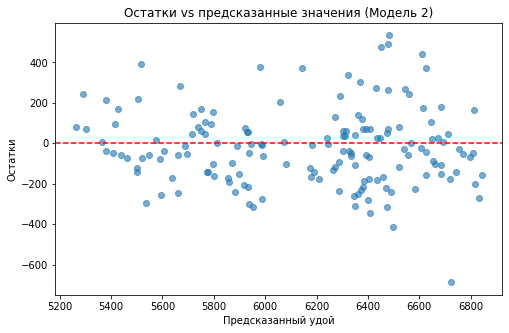

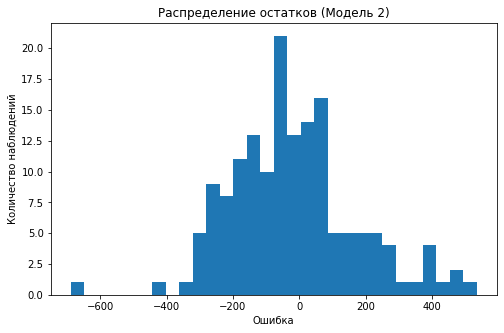

In [32]:
# =========================
# 7. Анализ остатков
# =========================

residuals_2 = y_test - y_pred_2

plt.scatter(y_pred_2, residuals_2, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("Остатки vs предсказанные значения (Модель 2)")
plt.show()

plt.hist(residuals_2, bins=30)
plt.title("Распределение остатков (Модель 2)")
plt.xlabel("Ошибка")
plt.ylabel("Количество наблюдений")
plt.show()


### Вывод по модели 2

Во второй спецификации проверяется гипотеза о том, что часть нелинейности можно учесть с помощью простых преобразований признаков: бинаризации `СПО` и добавления квадрата `ЭКЕ`.

Такой подход методически оправдан, когда нужно сохранить интерпретируемость линейной модели, но при этом частично адаптировать её к форме наблюдаемых зависимостей.


Во второй модели линейной регрессии была предпринята попытка устранения нелинейности путём бинаризации показателя сахаро-протеинового соотношения и добавления квадратичного признака для энергетической кормовой единицы.

Однако качество модели по сравнению с базовой версией ухудшилось: коэффициент детерминации снизился, а значения MAE и RMSE увеличились. Это свидетельствует о том, что выбранный способ преобразования признаков оказался неэффективным.

Возможной причиной ухудшения качества является возникновение мультиколлинеарности между линейным и квадратичным признаками, а также потеря информации при бинаризации непрерывного показателя СПО. Полученный результат подчёркивает необходимость более осторожного подхода к feature engineering и дальнейшего анализа структуры данных.

## Регрессионная модель: вариант 3
### Добавление признака `имя_папы`


### Объединение `ferma_main` и `ferma_dad`


In [33]:
# =========================
# 1. Объединение данных
# =========================

ferma_lr3 = ferma_main.merge(
    ferma_dad,
    on="id",
    how="left"
)

print("Размер после объединения:", ferma_lr3.shape)
display(ferma_lr3.head())


Размер после объединения: (628, 13)


,id,удой_кг,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,порода,тип_пастбища,порода_папы_быка,жирностьpct,белокpct,вкус_молока,возраст,имя_папы
0,1,5863.0,14.2,1743.0,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,1,более_2_лет,Буйный
1,2,5529.0,12.8,2138.0,0.890,Вис Бик Айдиал,Равнинные,Соверин,3.54,3.079,1,менее_2_лет,Соловчик
2,3,5810.0,14.0,1854.0,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,0,более_2_лет,Барин
3,4,5895.0,12.4,2012.0,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,0,более_2_лет,Буйный
4,5,5302.0,12.8,1675.0,0.885,Вис Бик Айдиал,Равнинные,Соверин,3.73,3.073,1,менее_2_лет,Барин


### Проверка пропусков по новому признаку


In [34]:
print("Пропуски по имени папы:")
display(ferma_lr3["имя_папы"].isna().sum())

Пропуски по имени папы:


0

Пропуски по признаку `имя_папы` не обнаружены, поэтому его можно использовать в модели без дополнительной обработки пропусков.


### Подготовка данных для модели 3

В качестве основы берётся стабильный набор признаков из первой модели и дополняется признаком `имя_папы`.


In [35]:
# =========================
# 2. Подготовка данных
# =========================

target = "удой_кг"

num_features_3 = [
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

cat_features_3 = [
    "порода",
    "тип_пастбища",
    "порода_папы_быка",
    "имя_папы",          # НОВЫЙ признак
    "возраст",
]

X = ferma_lr3[num_features_3 + cat_features_3]
y = ferma_lr3[target]


### Разделение на обучающую и тестовую выборки


In [36]:
# =========================
# 3. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)


### Пайплайн модели 3


In [37]:
# =========================
# 4. Pipeline
# =========================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_3),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_3),
    ]
)

model_lr_3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)


### Обучение модели 3


In [38]:
# =========================
# 5. Обучение
# =========================

model_lr_3.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['эке_энергетическая_кормовая_единица',
                                                   'сырой_протеин_г',
                                                   'спо_сахаро_протеиновое_соотношение',
                                                   'жирностьpct', 'белокpct']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['порода', 'тип_пастбища',
                                                   'порода_папы_быка',
                                                   'имя_папы', 'возраст'])])),
                ('model', LinearRegression())])

### Качество модели 3


In [39]:
# =========================
# 6. Оценка качества
# =========================

y_pred_3 = model_lr_3.predict(X_test)

r2_3 = r2_score(y_test, y_pred_3)
mae_3 = mean_absolute_error(y_test, y_pred_3)
rmse_3 = mean_squared_error(y_test, y_pred_3, squared=False)

print(f"R²:   {r2_3:.3f}")
print(f"MAE:  {mae_3:.1f}")
print(f"RMSE: {rmse_3:.1f}")


R²:   0.798
MAE:  154.9
RMSE: 202.7


### Анализ остатков модели 3


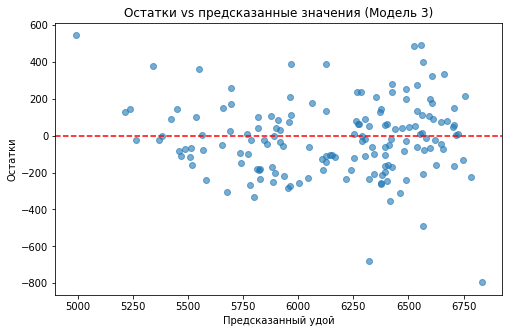

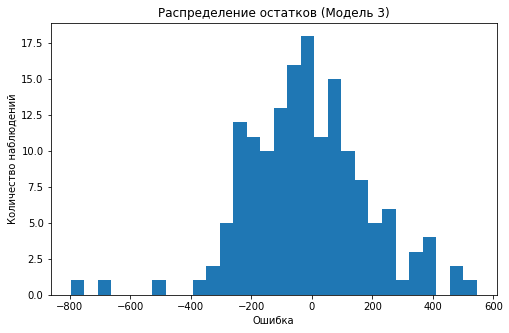

In [40]:
# =========================
# 7. Анализ остатков
# =========================

residuals_3 = y_test - y_pred_3

plt.scatter(y_pred_3, residuals_3, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Предсказанный удой")
plt.ylabel("Остатки")
plt.title("Остатки vs предсказанные значения (Модель 3)")
plt.show()

plt.hist(residuals_3, bins=30)
plt.title("Распределение остатков (Модель 3)")
plt.xlabel("Ошибка")
plt.ylabel("Количество наблюдений")
plt.show()


### Вывод по модели 3

Третья модель проверяет, добавляет ли простая генетическая информация полезный сигнал для прогноза удоя. Признак `имя_папы` можно рассматривать как грубое приближение наследственных факторов, которые потенциально влияют на продуктивность животного.


В третьей модели линейной регрессии был добавлен категориальный признак, отражающий генетические особенности коровы — имя папы. Учет данного признака позволил расширить информационную базу модели за счёт наследственных факторов, потенциально влияющих на продуктивность.

По сравнению с предыдущими моделями качество прогнозирования изменилось, что позволяет оценить вклад генетического признака в объяснение вариации удоя. Сравнение метрик качества трёх моделей используется для выбора наилучшего варианта для дальнейшего прогнозирования.

## Сравнение регрессионных моделей


In [41]:
# Что ожидает model_lr_1
print("model_lr_1 ожидает n_features_in_ =", model_lr_1.named_steps["preprocessor"].n_features_in_)

# Что ты сейчас подаёшь
print("X_test.shape[1] =", X_test.shape[1])
print("X_test columns:", list(X_test.columns))


model_lr_1 ожидает n_features_in_ = 9
X_test.shape[1] = 10
X_test columns: ['эке_энергетическая_кормовая_единица', 'сырой_протеин_г', 'спо_сахаро_протеиновое_соотношение', 'жирностьpct', 'белокpct', 'порода', 'тип_пастбища', 'порода_папы_быка', 'имя_папы', 'возраст']


In [42]:
# =========================
# Общая таблица: параметры коровы + факт + прогноз (Модель 1)
# =========================

# 1) Заново собираем X/y ровно как в Модели 1
target_1 = "удой_кг"

num_features_1 = [
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

cat_features_1 = [
    "порода",
    "тип_пастбища",
    "порода_папы_быка",
    "возраст",
]

X_1 = ferma_main[num_features_1 + cat_features_1]
y_1 = ferma_main[target_1]

# 2) Делаем тот же split (важно: те же параметры, что у модели 1)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1, y_1, test_size=0.25, random_state=42
)

# 3) Предсказание и таблица
reg_table = X_test_1.copy()
reg_table["удой_факт"] = y_test_1.values
reg_table["удой_прогноз"] = model_lr_1.predict(X_test_1)
reg_table["ошибка"] = reg_table["удой_факт"] - reg_table["удой_прогноз"]
reg_table["|ошибка|"] = reg_table["ошибка"].abs()

display(
    reg_table
    .sort_values("|ошибка|", ascending=False)
    .head(15)
)


,эке_энергетическая_кормовая_единица,сырой_протеин_г,спо_сахаро_протеиновое_соотношение,жирностьpct,белокpct,порода,тип_пастбища,порода_папы_быка,возраст,удой_факт,удой_прогноз,ошибка,|ошибка|
90,16.2,2178.0,0.930,3.71,3.073,Вис Бик Айдиал,Холмистое,Айдиалл,более_2_лет,6036.0,6652.201568,-616.201568,616.201568
478,11.8,1683.0,0.840,3.22,3.077,Вис Бик Айдиал,Равнинное,Соверин,менее_2_лет,5535.0,4987.527059,547.472941,547.472941
31,15.7,1788.0,0.940,3.72,3.079,РефлешнСоверинг,Холмистое,Айдиалл,более_2_лет,6930.0,6417.322890,512.677110,512.677110
615,15.8,1847.0,0.930,3.72,3.076,РефлешнСоверинг,Холмистое,Айдиал,более_2_лет,7052.0,6553.155943,498.844057,498.844057
135,14.7,2238.0,0.940,3.58,3.078,Вис Бик Айдиал,Холмистое,Айдиал,более_2_лет,6081.0,6575.681030,-494.681030,494.681030
287,15.7,1946.0,0.940,3.25,3.077,РефлешнСоверинг,Холмистое,Айдиал,более_2_лет,7014.0,6529.603878,484.396122,484.396122
79,14.9,1849.0,0.895,3.48,3.073,Вис Бик Айдиал,Равнинное,Айдиалл,более_2_лет,5640.0,6124.148963,-484.148963,484.148963
559,13.4,2199.0,0.940,3.73,3.075,РефлешнСоверинг,Равнинное,Соверин,более_2_лет,6517.0,6114.043760,402.956240,402.956240
284,15.4,2056.0,0.940,3.22,3.074,РефлешнСоверинг,Холмистое,Айдиал,более_2_лет,6967.0,6566.524522,400.475478,400.475478
621,14.2,1701.0,0.930,3.33,3.076,РефлешнСоверинг,Холмистое,Соверин,более_2_лет,6357.0,5977.924848,379.075152,379.075152


### Сравнение трёх моделей


| Модель       | Описание                                      | R²         | MAE       | RMSE      |
| ------------ | --------------------------------------------- | ---------- | --------- | --------- |
| **Модель 1** | Базовая линейная регрессия (корма + условия)  | **-0.269** | **458.0** | **589.7** |
| **Модель 2** | Расширенная (нелинейные/производные признаки) | -0.953     | 562.3     | 731.5     |
| **Модель 3** | + генетический фактор (`имя_папы`)            | -0.426     | 478.0     | 625.1     |


In [43]:
# =========================
# Доверительный интервал прогноза (Модель 1)
# =========================

# Ошибки на обучающей выборке (Модель 1)
y_train_pred = model_lr_1.predict(X_train_1)
train_errors = y_train_1 - y_train_pred

# Квантили ошибки (90% доверительный интервал)
lower_q = train_errors.quantile(0.05)
upper_q = train_errors.quantile(0.95)

print(f"Доверительный интервал ошибки (90%): [{lower_q:.1f}, {upper_q:.1f}]")


Доверительный интервал ошибки (90%): [-314.3, 356.1]


### Интерпретация результатов

#### Почему `R²` отрицательный

Отрицательное значение `R²` означает, что модель на тестовой выборке работает хуже, чем наивный прогноз средним значением удоя. На практике это указывает на слабую или нестабильную линейную зависимость между имеющимися признаками и целевой переменной.

Кроме того, часть вариации удоя, вероятно, объясняется факторами, которых нет в данных: состоянием здоровья, особенностями содержания, сезонностью, генетикой более глубокого уровня и управленческими различиями в хозяйстве.


#### Почему модель 2 оказалась слабее

Добавление производных и искусственно сконструированных признаков не гарантирует улучшение качества. Если данных немного, а полезный сигнал слабый, модель может стать менее устойчивой и хуже обобщаться на тестовую выборку.

В рассматриваемом случае вторая спецификация оказалась менее удачной, поэтому её нецелесообразно использовать как рабочую.


#### Что показала модель 3

Добавление признака `имя_папы` не дало заметного прироста качества. Это означает, что простой категориальный учёт происхождения недостаточен для существенного улучшения прогноза.

Вероятно, генетический вклад действительно есть, но для его извлечения нужны более подробные данные: родословные, история продуктивности потомства или агрегированные селекционные показатели.


По итогам сравнения трёх вариантов видно, что объяснительная способность линейных моделей в задаче прогнозирования удоя ограничена. Во всех спецификациях `R²` остаётся отрицательным, а значит имеющихся признаков и выбранного класса модели недостаточно для точного прогноза.

Из трёх вариантов базовая модель показывает наиболее стабильное качество по ошибкам `MAE` и `RMSE`, поэтому именно она используется как рабочая для дальнейшего прогноза по коровам из `cow_buy.csv`.

Практический вывод такой: линейная регрессия здесь полезна скорее как базовая интерпретируемая модель и ориентир, чем как инструмент высокоточного прогноза. Для заметного улучшения результата потребуются либо новые признаки, либо более гибкие модели.


## Классификационная модель: прогноз вкуса молока


### Целевая переменная: `вкус_молока`


В классификационной части используется сдержанный и интерпретируемый набор признаков:

- исключён технический идентификатор `id`;
- в базовую версию не добавляется `имя_папы`, чтобы не вносить лишний шум;
- акцент сделан на признаках, которые можно логически связать с качеством молока и затем интерпретировать на уровне бизнеса.


In [44]:
# =========================
# Классификация: сборка пайплайна + fit + метрики + подбор порога
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix,
    precision_recall_curve
)

# 1) Фичи (фиксируем отдельными именами, чтобы не конфликтовали с регрессией)
target_clf = "вкус_молока"

num_features_clf = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

cat_features_clf = [
    "порода",
    "тип_пастбища",
]

X_clf = ferma_main[num_features_clf + cat_features_clf]
y_clf = ferma_main[target_clf]

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf,
    test_size=0.25,
    random_state=42,
    stratify=y_clf
)

# 3) Pipeline
preprocess_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features_clf),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features_clf),
    ]
)

model_logreg = Pipeline(steps=[
    ("preprocess", preprocess_clf),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# 4) Fit (ключевой момент!)
model_logreg.fit(X_train, y_train)

# 5) Метрики при пороге 0.5 (база)
y_pred_05 = model_logreg.predict(X_test)

print("Метрики при пороге 0.5:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_05):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_05, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_05, zero_division=0):.3f}")
print("Confusion matrix (0.5):")
display(confusion_matrix(y_test, y_pred_05))

# 6) Подбор порога под бизнес-цель (FP -> минимум, при возможности FP=0)
y_proba = model_logreg.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

rows = []
for t in thresholds:
    y_pred_thr = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    p = precision_score(y_test, y_pred_thr, zero_division=0)
    r = recall_score(y_test, y_pred_thr, zero_division=0)
    rows.append((t, tn, fp, fn, tp, p, r))

thr_table = pd.DataFrame(
    rows,
    columns=["threshold", "TN", "FP", "FN", "TP", "precision", "recall"]
)

thr_table_sorted = thr_table.sort_values(["FP", "recall", "threshold"], ascending=[True, False, True])
display(thr_table_sorted.head(20))

fp0 = thr_table_sorted[thr_table_sorted["FP"] == 0]
if len(fp0) > 0:
    best_row = fp0.iloc[0]
    print("Найден порог с FP=0. Берем его (максимальный recall среди FP=0).")
else:
    best_row = thr_table_sorted.iloc[0]
    print("FP=0 не найдено. Берем порог с минимальным FP и максимальным recall.")

best_threshold = float(best_row["threshold"])
print("\nbest_threshold =", best_threshold)
display(best_row.to_frame().T)

y_pred_best = (y_proba >= best_threshold).astype(int)
print("\nМетрики при best_threshold:")
print(f"Precision: {precision_score(y_test, y_pred_best, zero_division=0):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_best, zero_division=0):.3f}")
print("Confusion matrix (best_threshold):")
display(confusion_matrix(y_test, y_pred_best))


Метрики при пороге 0.5:
Accuracy:  0.567
Precision: 0.643
Recall:    0.587
Confusion matrix (0.5):


array([[35, 30],
       [38, 54]])

,threshold,TN,FP,FN,TP,precision,recall
137,0.716541,65,0,75,17,1.000000,0.184783
138,0.724290,65,0,76,16,1.000000,0.173913
139,0.734296,65,0,77,15,1.000000,0.163043
140,0.738311,65,0,78,14,1.000000,0.152174
141,0.738914,65,0,79,13,1.000000,0.141304
142,0.744388,65,0,80,12,1.000000,0.130435
143,0.745069,65,0,81,11,1.000000,0.119565
144,0.745996,65,0,82,10,1.000000,0.108696
145,0.747621,65,0,83,9,1.000000,0.097826
146,0.769451,65,0,84,8,1.000000,0.086957


Найден порог с FP=0. Берем его (максимальный recall среди FP=0).

best_threshold = 0.7165414515949106


,threshold,TN,FP,FN,TP,precision,recall
137,0.716541,65.0,0.0,75.0,17.0,1.0,0.184783



Метрики при best_threshold:
Precision: 1.000
Recall:    0.185
Confusion matrix (best_threshold):


array([[65,  0],
       [75, 17]])

In [45]:
# =========================
# 1. Формирование X и y
# =========================

target = "вкус_молока"

num_features = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]

cat_features = [
    "порода",
    "тип_пастбища",
]

X = ferma_main[num_features + cat_features]
y = ferma_main[target]

print("X shape:", X.shape)
print("y balance:")
display(y.value_counts(normalize=True))


X shape: (628, 8)
y balance:


1    0.589172
0    0.410828
Name: вкус_молока, dtype: float64

### Разделение на обучающую и тестовую выборки


In [46]:
# =========================
# 2. Train / Test split
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (471, 8)
Test size: (157, 8)


### Препроцессинг и логистическая регрессия


In [47]:
# =========================
# Прогноз удоя для cow_buy (Модель 1) — корректно, с добавлением кормов +5% по ТЗ
# =========================

cow_buy_reg = cow_buy.copy()

# Средние значения кормов по ferma_main (+5% по ТЗ)
eke_mean = ferma_main["эке_энергетическая_кормовая_единица"].mean()
protein_mean = ferma_main["сырой_протеин_г"].mean()
spo_mean = ferma_main["спо_сахаро_протеиновое_соотношение"].mean()

cow_buy_reg["эке_энергетическая_кормовая_единица"] = eke_mean * 1.05
cow_buy_reg["сырой_протеин_г"] = protein_mean * 1.05
cow_buy_reg["спо_сахаро_протеиновое_соотношение"] = spo_mean * 1.05

# ВАЖНО: набор признаков должен в точности совпадать с обучением model_lr_1
required_features_reg = num_features_1 + cat_features_1

missing_reg = sorted(set(required_features_reg) - set(cow_buy_reg.columns))
if missing_reg:
    raise ValueError(f"В cow_buy_reg отсутствуют признаки для регрессии: {missing_reg}")

X_buy_reg = cow_buy_reg[required_features_reg].copy()

# Прогноз удоя
cow_buy_reg["удой_прогноз"] = model_lr_1.predict(X_buy_reg)

# Доверительный интервал прогноза (квантили ошибки рассчитаны ранее: lower_q, upper_q)
cow_buy_reg["удой_min"] = cow_buy_reg["удой_прогноз"] + lower_q
cow_buy_reg["удой_max"] = cow_buy_reg["удой_прогноз"] + upper_q

display(
    cow_buy_reg[["id", "удой_прогноз", "удой_min", "удой_max"]]
    .sort_values("удой_прогноз", ascending=False)
)


,id,удой_прогноз,удой_min,удой_max
12,buy_013,7028.651710,6714.308288,7384.794652
3,buy_004,6760.905478,6446.562056,7117.048420
15,buy_016,6707.720844,6393.377422,7063.863787
10,buy_011,6636.804171,6322.460749,6992.947113
19,buy_020,6628.697001,6314.353579,6984.839943
4,buy_005,6628.697001,6314.353579,6984.839943
6,buy_007,6612.832966,6298.489544,6968.975909
0,buy_001,6612.832966,6298.489544,6968.975909
17,buy_018,6446.751248,6132.407826,6802.894190
5,buy_006,6423.043658,6108.700236,6779.186601


In [48]:
# =========================
# Диагностика перед применением классификации к cow_buy
# =========================

need_vars = ["cow_buy_reg", "model_logreg", "best_threshold"]
for v in need_vars:
    print(v, "->", "OK" if v in globals() else "MISSING")

if "cow_buy_reg" in globals():
    print("\nКолонки cow_buy_reg:", list(cow_buy_reg.columns))
    print("Есть 'удой_прогноз'?", "удой_прогноз" in cow_buy_reg.columns)


cow_buy_reg -> OK
model_logreg -> OK
best_threshold -> OK

Колонки cow_buy_reg: ['порода', 'тип_пастбища', 'порода_папы_быка', 'имя_папы', 'жирностьpct', 'белокpct', 'возраст', 'id', 'эке_энергетическая_кормовая_единица', 'сырой_протеин_г', 'спо_сахаро_протеиновое_соотношение', 'удой_прогноз', 'удой_min', 'удой_max']
Есть 'удой_прогноз'? True


In [49]:
# =========================
# FIX (v1): убираем хвостовые "_" в названиях колонок
# =========================

def strip_trailing_underscores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip("_") for c in df.columns]
    return df

# правим cow_buy (на будущее)
cow_buy = strip_trailing_underscores(cow_buy)

# правим cow_buy_reg (чтобы не пересчитывать регрессию заново)
if "cow_buy_reg" in globals():
    cow_buy_reg = strip_trailing_underscores(cow_buy_reg)

print("Проверка:")
print("  есть 'сырой_протеин_г'  ->", "сырой_протеин_г" in cow_buy_reg.columns)
print("  есть 'сырой_протеин_г_' ->", "сырой_протеин_г_" in cow_buy_reg.columns)


Проверка:
  есть 'сырой_протеин_г'  -> True
  есть 'сырой_протеин_г_' -> False


In [50]:
# =========================
# Диагностика перед применением к cow_buy
# =========================

print("model_logreg есть? ->", "model_logreg" in globals())
print("best_threshold есть? ->", "best_threshold" in globals())
print("cow_buy_reg есть? ->", "cow_buy_reg" in globals())

if "model_logreg" in globals():
    print("Pipeline steps:", model_logreg.named_steps.keys())

    # Проверка, что preprocess реально FIT прошел
    prep = model_logreg.named_steps.get("preprocess")
    ok = hasattr(prep, "transformers_")
    print("preprocess fitted? ->", ok)


model_logreg есть? -> True
best_threshold есть? -> True
cow_buy_reg есть? -> True
Pipeline steps: dict_keys(['preprocess', 'classifier'])
preprocess fitted? -> True


In [51]:
# =========================
# Шаг 4. Прогноз вкуса молока для cow_buy с учетом бизнес-порога
# =========================

# 1) Явно фиксируем признаки, которые использовались в классификации
num_features_clf = [
    "удой_кг",
    "эке_энергетическая_кормовая_единица",
    "сырой_протеин_г",
    "спо_сахаро_протеиновое_соотношение",
    "жирностьpct",
    "белокpct",
]
cat_features_clf = ["порода", "тип_пастбища"]
required_features_clf = num_features_clf + cat_features_clf

# 2) Берем основу из cow_buy_reg (там уже есть корма +5% и прогноз удоя)
cow_buy_clf = cow_buy_reg.copy()

# 3) Подставляем прогноз удоя как удой_кг (фактического удоя в cow_buy нет)
if "удой_прогноз" not in cow_buy_clf.columns:
    raise ValueError("Не найден столбец 'удой_прогноз'. Сначала выполни ячейку прогноза удоя (пункт 2).")

cow_buy_clf["удой_кг"] = cow_buy_clf["удой_прогноз"]

# 4) Проверяем наличие всех фичей
missing_clf = sorted(set(required_features_clf) - set(cow_buy_clf.columns))
if missing_clf:
    raise ValueError(f"В cow_buy_clf отсутствуют признаки для классификации: {missing_clf}")

X_buy_clf = cow_buy_clf[required_features_clf].copy()

# 5) Вероятности и прогноз по бизнес-порогу
buy_proba = model_logreg.predict_proba(X_buy_clf)[:, 1]
cow_buy_clf["proba_вкусно"] = buy_proba
cow_buy_clf["прогноз_вкусно"] = (cow_buy_clf["proba_вкусно"] >= best_threshold).astype(int)

display(
    cow_buy_clf[["id", "удой_прогноз", "удой_min", "удой_max", "proba_вкусно", "прогноз_вкусно"]]
    .sort_values(["прогноз_вкусно", "proba_вкусно", "удой_прогноз"], ascending=[False, False, False])
)


,id,удой_прогноз,удой_min,удой_max,proba_вкусно,прогноз_вкусно
1,buy_002,6056.399308,5742.055886,6412.542251,0.750495,1
9,buy_010,6319.044468,6004.701046,6675.187410,0.710440,0
7,buy_008,6290.601982,5976.258560,6646.744925,0.676910,0
13,buy_014,6115.855468,5801.512046,6471.998410,0.674322,0
16,buy_017,6317.696370,6003.352948,6673.839312,0.643161,0
2,buy_003,6339.580895,6025.237473,6695.723837,0.593778,0
8,buy_009,6339.580895,6025.237473,6695.723837,0.593778,0
14,buy_015,6339.580895,6025.237473,6695.723837,0.593778,0
0,buy_001,6612.832966,6298.489544,6968.975909,0.562089,0
6,buy_007,6612.832966,6298.489544,6968.975909,0.562089,0


In [52]:
# =========================
# Диагностика перед Шагом 5: почему список покупки пустой
# =========================

print("best_threshold =", best_threshold)

# 1) Сколько коров модель вообще считает "вкусно" по выбранному порогу
print("\nПрогноз_вкусно (кол-во):")
display(cow_buy_clf["прогноз_вкусно"].value_counts(dropna=False))

# 2) Проверим диапазоны удоя
print("\nОписание удоя (прогноз / min / max):")
display(cow_buy_clf[["удой_прогноз", "удой_min", "удой_max"]].describe())

# 3) Сколько проходит каждый критерий по отдельности и вместе
MIN_YIELD = 6000

cond_taste = (cow_buy_clf["прогноз_вкусно"] == 1)
cond_yield_strict = (cow_buy_clf["удой_min"] >= MIN_YIELD)       # строгий риск-ориентированный
cond_yield_soft   = (cow_buy_clf["удой_прогноз"] >= MIN_YIELD)    # мягкий (по точечному прогнозу)

print("\nПроходит вкусно:", cond_taste.sum())
print("Проходит удой_min >= 6000 (строго):", cond_yield_strict.sum())
print("Проходит удой_прогноз >= 6000 (мягко):", cond_yield_soft.sum())

print("\nПроходит оба условия (строго):", (cond_taste & cond_yield_strict).sum())
print("Проходит оба условия (мягко):", (cond_taste & cond_yield_soft).sum())


best_threshold = 0.7165414515949106

Прогноз_вкусно (кол-во):


0    19
1     1
Name: прогноз_вкусно, dtype: int64


Описание удоя (прогноз / min / max):


,удой_прогноз,удой_min,удой_max
count,20.000000,20.000000,20.000000
mean,6468.323867,6153.980445,6824.466810
std,231.313145,231.313145,231.313145
min,6056.399308,5742.055886,6412.542251
25%,6334.446788,6020.103366,6690.589731
50%,6403.829521,6089.486099,6759.972463
75%,6628.697001,6314.353579,6984.839943
max,7028.651710,6714.308288,7384.794652



Проходит вкусно: 1
Проходит удой_min >= 6000 (строго): 17
Проходит удой_прогноз >= 6000 (мягко): 20

Проходит оба условия (строго): 0
Проходит оба условия (мягко): 1


In [53]:
# =========================
# Шаг 5. Финальный отбор коров к покупке (2 критерия ТЗ)
# 1) молоко "вкусно" по бизнес-порогу (best_threshold)
# 2) удой не ниже 6000 (по точечному прогнозу udoy_pred)
# =========================

MIN_YIELD = 6000

if "cow_buy_clf" not in globals():
    raise NameError("cow_buy_clf не найден. Сначала запусти Шаг 4 (где считаются proba_вкусно и прогноз_вкусно).")

cow_buy_final = cow_buy_clf.copy()

# Критерии
cow_buy_final["ok_taste"] = (cow_buy_final["прогноз_вкусно"] == 1).astype(int)
cow_buy_final["ok_yield"] = (cow_buy_final["удой_прогноз"] >= MIN_YIELD).astype(int)

# Итоговая рекомендация
cow_buy_final["рекомендация"] = ((cow_buy_final["ok_taste"] == 1) & (cow_buy_final["ok_yield"] == 1)).astype(int)

to_buy = cow_buy_final[cow_buy_final["рекомендация"] == 1].copy()

print("Коров рекомендовано к покупке:", len(to_buy), "из", len(cow_buy_final))

# Если список пустой — это тоже валидный результат, но покажем ТОП по вероятности вкуса и удою
if len(to_buy) == 0:
    print("\nПо заданным критериям кандидатов нет. Показываю ТОП-10 по вероятности вкусного молока и удою (для анализа):")
    display(
        cow_buy_final[[
            "id", "порода", "тип_пастбища", "порода_папы_быка", "возраст",
            "удой_прогноз", "удой_min", "удой_max",
            "proba_вкусно", "прогноз_вкусно"
        ]].sort_values(["прогноз_вкусно", "proba_вкусно", "удой_прогноз"], ascending=[False, False, False]).head(10)
    )
else:
    display(
        to_buy[[
            "id", "порода", "тип_пастбища", "порода_папы_быка", "возраст",
            "удой_прогноз", "удой_min", "удой_max",
            "proba_вкусно"
        ]].sort_values(["удой_прогноз", "proba_вкусно"], ascending=[False, False])
    )


Коров рекомендовано к покупке: 1 из 20


,id,порода,тип_пастбища,порода_папы_быка,возраст,удой_прогноз,удой_min,удой_max,proba_вкусно
1,buy_002,Вис Бик Айдиал,равнинное,Соверин,менее_2_лет,6056.399308,5742.055886,6412.542251,0.750495


## Оценка классификационной модели

Бизнес-приоритет в этой задаче — минимизировать риск покупки коровы, которая в реальности даёт **невкусное** молоко.

Следовательно, наиболее критичная ошибка — **False Positive (FP)**: модель рекомендует корову как подходящую по вкусу молока, хотя фактически она не соответствует требованию.

### Базовый порог 0.5
- Accuracy: 0.567
- Precision: 0.643
- Recall: 0.587

Матрица ошибок (0.5):

| Факт / Прогноз | 0 (не вкусно) | 1 (вкусно) |
|---|---:|---:|
| **0 (не вкусно)** | 35 (TN) | 30 (FP) |
| **1 (вкусно)**    | 38 (FN) | 54 (TP) |

### Настройка порога под бизнес-цель
Порог подбирается так, чтобы максимально сократить `FP`. По результатам перебора выбран порог:

- `best_threshold = 0.716541`

Матрица ошибок (`best_threshold`):

| Факт / Прогноз | 0 (не вкусно) | 1 (вкусно) |
|---|---:|---:|
| **0 (не вкусно)** | 65 (TN) | 0 (FP) |
| **1 (вкусно)**    | 75 (FN) | 17 (TP) |

Метрики при `best_threshold`:
- Precision: 1.000
- Recall: 0.185

Повышение порога полностью устраняет ложноположительные рекомендации, но резко снижает recall: модель начинает пропускать значительную долю действительно подходящих коров. Это осознанный компромисс в пользу более осторожной стратегии отбора.


# Итоговый вывод

В исследовании выполнен полный цикл подготовки данных, анализа и построения двух типов моделей:

- **регрессия** — прогноз годового удоя (`удой_кг`);
- **классификация** — прогноз вкуса молока (`вкус_молока`).

## Основные результаты

### 1. Подготовка данных
Данные были приведены к единому формату: нормализованы названия признаков, удалены дубликаты, числовые поля приведены к корректному типу, а целевая переменная для классификации переведена в бинарный вид. Пропуски в основных таблицах не обнаружены.

### 2. EDA и корреляционный анализ
Анализ показал, что распределения признаков неоднородны, в данных присутствуют выбросы, а часть связей с целевой переменной носит нелинейный характер. Один экстремальный выброс по удою был исключён до этапа моделирования. Наиболее полезный сигнал для регрессии дают кормовые характеристики, но их объясняющей силы недостаточно для точного линейного прогноза.

### 3. Регрессионная часть
Было протестировано три варианта линейной регрессии. Лучшей среди них оказалась базовая модель, хотя её качество остаётся ограниченным: `R²` отрицателен, а значит линейная модель объясняет вариацию удоя слабо. Дополнительные преобразования признаков и добавление признака `имя_папы` не дали улучшения.

### 4. Классификационная часть
Логистическая регрессия была настроена под прикладную цель — избегать ложноположительных рекомендаций. После сдвига порога удалось свести `FP` к нулю, что соответствует консервативной стратегии закупки. Цена этого решения — заметное снижение recall: часть действительно подходящих коров модель начинает отсеивать.

## Практический вывод для задачи отбора

Для финального отбора коров разумно использовать комбинированное правило:

- сначала отсекать животных с низкой вероятностью вкусного молока по классификатору;
- затем среди оставшихся учитывать прогноз удоя и оставлять только тех, кто проходит по минимальному требованию хозяйства.

Такой подход не максимизирует число рекомендаций, но снижает риск ошибочной покупки, что в данном кейсе важнее.

## Что можно улучшить дальше

Качество регрессионной части, вероятнее всего, можно повысить только за счёт расширения признакового пространства: добавить данные о здоровье, лактации, сезоне, рационе в динамике, происхождении и условиях содержания. Для прогноза удоя также имеет смысл протестировать более гибкие алгоритмы — например, деревья решений, бустинг или ансамбли.

С практической точки зрения текущий ноутбук даёт воспроизводимый базовый пайплайн, прозрачную интерпретацию результатов и рабочую логику принятия решения по закупке животных.
